# clustering on Wholesale data

✔ Dataset Size

    440 rows
    8 columns

✔ Type of Data

    All columns are integer (int64) → numerical data only.

1. Channel

Categorical (encoded as numbers)

Values:
    1 = Horeca (Hotel/Restaurant/Café)
    2 = Retail

2. Region

Categorical (encoded as numbers)

Values:
    1 = Lisbon
    2 = Oporto
    3 = Other regions

Even though stored as integers, Channel and Region are categorical, not continuous numbers.


| Column               | Type       | Meaning                                 |
| -------------------- | ---------- | --------------------------------------- |
| **Fresh**            | Continuous | Budget spent on fresh products          |
| **Milk**             | Continuous | Spending on milk                        |
| **Grocery**          | Continuous | Spending on groceries                   |
| **Frozen**           | Continuous | Spending on frozen items                |
| **Detergents_Paper** | Continuous | Spending on detergents & paper products |
| **Delicassen**       | Continuous | Spending on delicatessen                |


In [1]:

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

data = pd.read_csv('Wholesale customers data.csv')
data

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125



Each row = one customer

Each column = how much they buy of each item

                Fresh, Milk, Grocery, Frozen, Detergents, Delicassen


In [3]:

data.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

In [4]:

data['Channel'].unique()

array([2, 1], dtype=int64)

In [5]:

data['Region'].unique()

array([3, 1, 2], dtype=int64)

In [6]:
categorical_features = ['Channel', 'Region']

continuous_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

In [7]:

for col in categorical_features:
    dummies = pd.get_dummies(data[col], prefix=col)
    data = pd.concat([data, dummies], axis=1)
    data.drop(col, axis=1, inplace=True)

data.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,True,False,False,True
1,7057,9810,9568,1762,3293,1776,False,True,False,False,True
2,6353,8808,7684,2405,3516,7844,False,True,False,False,True
3,13265,1196,4221,6404,507,1788,True,False,False,False,True
4,22615,5410,7198,3915,1777,5185,False,True,False,False,True


In [8]:

from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
mms.fit(data)
data_transformed = mms.transform(data)
data_transformed


array([[0.11294004, 0.13072723, 0.08146416, ..., 0.        , 0.        ,
        1.        ],
       [0.06289903, 0.13282409, 0.10309667, ..., 0.        , 0.        ,
        1.        ],
       [0.05662161, 0.11918086, 0.08278992, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.1295431 , 0.21013575, 0.32594285, ..., 0.        , 0.        ,
        1.        ],
       [0.091727  , 0.02622442, 0.02402535, ..., 0.        , 0.        ,
        1.        ],
       [0.02482434, 0.02237109, 0.02702178, ..., 0.        , 0.        ,
        1.        ]])

In [11]:

import warnings
warnings.filterwarnings('ignore')

In [12]:

Sum_of_squared_distances = []

K = range(2,21)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(data_transformed)
    Sum_of_squared_distances.append(km.inertia_)
    

In [13]:

Sum_of_squared_distances 

[213.39898477020844,
 117.07252399254907,
 79.04650314557736,
 50.209259066571086,
 19.418928179725285,
 16.868864806949016,
 14.06528301038374,
 12.18117932386385,
 11.129579792931375,
 9.73366017502188,
 9.532261635320635,
 8.574646562636405,
 8.879633055027517,
 7.926124501235524,
 7.132556206683673,
 6.354048292120674,
 6.240860151268312,
 6.2020515771463245,
 6.246141050011595]

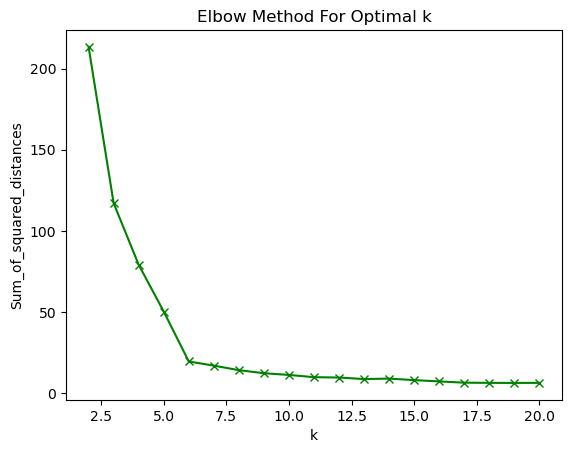

In [14]:

plt.plot(K, Sum_of_squared_distances, 'gx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()


In [15]:

kmeans = KMeans(n_clusters =5, init='k-means++')
kmeans.fit(data_transformed)
pred = kmeans.predict(data_transformed)
pred[:200]


array([3, 3, 3, 1, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 1, 3, 1, 3, 1,
       1, 3, 3, 3, 1, 1, 3, 1, 1, 1, 1, 1, 1, 3, 1, 3, 3, 1, 1, 1, 3, 3,
       3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 1, 1, 3, 3, 1, 1, 3, 3, 3, 3, 1, 3,
       1, 3, 1, 1, 1, 1, 1, 3, 3, 1, 1, 3, 1, 1, 1, 3, 3, 1, 3, 3, 3, 1,
       1, 1, 1, 1, 3, 1, 3, 1, 3, 1, 1, 1, 3, 3, 3, 1, 1, 1, 3, 3, 3, 3,
       1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3, 3, 1, 3, 3, 3, 1, 1, 3, 3, 3, 3, 1, 1, 1, 3, 3, 1, 3, 1, 3,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1, 3, 1, 1, 2, 4,
       2, 2])

In [16]:

frame = pd.DataFrame(data_transformed)
frame['cluster'] = pred

In [17]:

frame

,0,1,2,3,4,5,6,7,8,9,10,cluster
0,0.112940,0.130727,0.081464,0.003106,0.065427,0.027847,0.0,1.0,0.0,0.0,1.0,3
1,0.062899,0.132824,0.103097,0.028548,0.080590,0.036984,0.0,1.0,0.0,0.0,1.0,3
2,0.056622,0.119181,0.082790,0.039116,0.086052,0.163559,0.0,1.0,0.0,0.0,1.0,3
3,0.118254,0.015536,0.045464,0.104842,0.012346,0.037234,1.0,0.0,0.0,0.0,1.0,1
4,0.201626,0.072914,0.077552,0.063934,0.043455,0.108093,0.0,1.0,0.0,0.0,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
435,0.264829,0.163338,0.172715,0.215469,0.004385,0.045912,1.0,0.0,0.0,0.0,1.0,1
436,0.349761,0.018736,0.008202,0.073713,0.002205,0.048874,1.0,0.0,0.0,0.0,1.0,1
437,0.129543,0.210136,0.325943,0.006771,0.363463,0.038882,0.0,1.0,0.0,0.0,1.0,3
438,0.091727,0.026224,0.024025,0.016649,0.004042,0.044264,1.0,0.0,0.0,0.0,1.0,1


In [18]:

frame['cluster'].value_counts()

cluster
1    211
3    105
2     59
4     37
0     28
Name: count, dtype: int64

# Ver 2

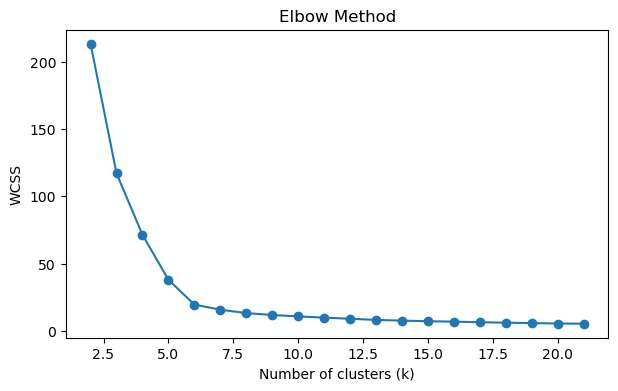

Cluster
1    211
0    142
2     87
Name: count, dtype: int64


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('Wholesale customers data.csv')

data_encoded = pd.get_dummies(
    data,
    columns=['Channel', 'Region'],
    drop_first=False
)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_encoded)

wcss = []
K = range(2, 22)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)

data['Cluster'] = clusters

print(data['Cluster'].value_counts())


In [21]:

cluster_profile = data.groupby('Cluster').mean()

cluster_profile

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,2.0,2.612676,8904.323944,10716.500000,16322.852113,1652.612676,7269.507042,1753.436620
1,1.0,3.000000,13878.052133,3486.981043,3886.734597,3656.900474,786.682464,1518.284360
2,1.0,1.321839,12499.402299,3366.218391,4145.011494,3969.804598,799.965517,1167.781609


<Axes: xlabel='Cluster'>

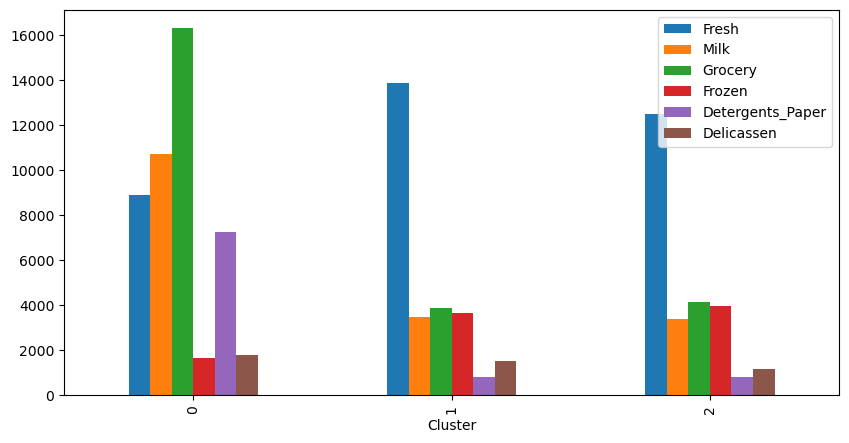

In [22]:

data.groupby('Cluster')[[
    'Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen'
]].mean().plot(kind='bar', figsize=(10,5))


One VERY SIMPLE RULE (remember this)

    Highest Grocery + Detergents → Retail
    
    Highest Fresh + Frozen → Restaurants
    
    Everything medium → Small buyers
    

### metrics

In [23]:
from sklearn.metrics import silhouette_score

In [24]:

silhouette_avg = silhouette_score(data_scaled, clusters)
print(f"Silhouette Score for k=3: {silhouette_avg:.3f}")


Silhouette Score for k=3: 0.676


In [25]:
from sklearn.metrics import silhouette_score

sil_scores = []

K = range(2, 22)   # silhouette not defined for k=1

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    sil_scores.append(score)

for k, s in zip(K, sil_scores):
    print(f"k={k} → Silhouette Score = {s:.3f}")


k=2 → Silhouette Score = 0.568
k=3 → Silhouette Score = 0.676
k=4 → Silhouette Score = 0.752
k=5 → Silhouette Score = 0.814
k=6 → Silhouette Score = 0.849
k=7 → Silhouette Score = 0.825
k=8 → Silhouette Score = 0.670
k=9 → Silhouette Score = 0.655
k=10 → Silhouette Score = 0.585
k=11 → Silhouette Score = 0.600
k=12 → Silhouette Score = 0.537
k=13 → Silhouette Score = 0.541
k=14 → Silhouette Score = 0.496
k=15 → Silhouette Score = 0.499
k=16 → Silhouette Score = 0.452
k=17 → Silhouette Score = 0.459
k=18 → Silhouette Score = 0.359
k=19 → Silhouette Score = 0.359
k=20 → Silhouette Score = 0.372
k=21 → Silhouette Score = 0.345


### analysis

🟦 Cluster 0 → Retail stores 🏪

Look at Cluster 0 numbers:

    Grocery → 16,322 (VERY HIGH)
    
    Detergents → 7,269 (VERY HIGH)
    
    Milk → 10,716 (HIGH)
    
    Fresh → 8,904 (ok)
    
    Frozen → 1,652 (low)

Simple thinking: 

Who buys:

    A LOT of grocery items?

    A LOT of detergents & cleaning products?

    Packaged milk?

👉 Retail / grocery shops

✅ So Cluster 0 = Retail stores

🟧 Cluster 1 → Restaurants 🍽️

Look at Cluster 1:

    Fresh → 13,878 (VERY HIGH)
    
    Frozen → 3,656 (HIGH)
    
    Grocery → 3,886 (LOW)
    
    Detergents → 787 (LOW)

Simple thinking:

Who buys lots of:

    Vegetables, meat, fish? (Fresh)
    
    Frozen food?
    But NOT much grocery or detergents?

👉 Restaurants & hotels

They:

    Cook food daily
    
    Need fresh & frozen ingredients
    
    Don’t resell packaged goods

✅ So Cluster 1 = Restaurants

🟨 Cluster 2 → Small shops / mixed buyers 🏬

Look at Cluster 2:

    Fresh → 12,499 (medium-high)
    
    Grocery → 4,145 (medium)
    
    Frozen → 3,969 (medium)
    
    Detergents → 800 (medium)

Simple thinking:

Who buys:

    A little of everything?
    
    But not huge amounts of anything?

👉 Small shops, cafes, local vendors

They:

    Don’t specialize
    
    Buy moderately across categories

✅ So Cluster 2 = Small buyers